# SmartMatch AI – LLM-Judge Evaluation Plots

All plots use the project brand palette: **MF1131** (crimson), **MF0883** (gold), **MF0473** (teal), **MF0935** (amber).

In [31]:

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import textwrap

# ─── Brand palette ───────────────────────────────────────────────────────────
C = {
    'crimson':  '#951d2f',   # MF1131
    'gold':     '#E7BB70',   # MF0883
    'teal':     '#27524A',   # MF0473
    'amber':    '#DC9133',   # MF0935
    'bg':       '#FAF7F2',   # warm off-white background
    'text':     '#1A1A1A',
    'grid':     '#E0DAD0',
}
PALETTE  = [C['crimson'], C['teal'], C['gold'], C['amber']]
PALETTE2 = [C['teal'],    C['crimson']]

# Global rcParams
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'axes.facecolor':     C['bg'],
    'figure.facecolor':   C['bg'],
    'axes.edgecolor':     C['grid'],
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.color':         C['grid'],
    'grid.linewidth':     0.6,
    'axes.labelcolor':    C['text'],
    'xtick.color':        C['text'],
    'ytick.color':        C['text'],
    'text.color':         C['text'],
    'font.size':          11,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.labelsize':     10.5,
})

PLOT_DIR = Path('results/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv('results/llm_judge_results.csv')
criteria  = ['Relevance', 'Visual_Quality', 'Coherence', 'Aesthetics']
labels    = ['Relevance', 'Visual\nQuality', 'Coherence', 'Aesthetics']
labels_1L = ['Relevance', 'Visual Quality', 'Coherence', 'Aesthetics']

print(f"Loaded {len(df)} rows")
df.head(3)


Loaded 50 rows


,query_id,query,Relevance,Visual_Quality,Coherence,Aesthetics,mean_score,n_images,n_retrieved,n_generated,routing_decision,top_hybrid_score,board_summary_len,reasoning,error
0,1,feeling burnt out after a long week,5,2,4,2,3.25,9,0,9,generation,0.3716,755,The board is conceptually excellent—every imag...,NaN
1,2,celebrating a new job offer,4,3,3,3,3.25,9,2,7,retrieval,0.4054,643,The board successfully captures the job celebr...,NaN
2,3,quiet sunday morning with coffee,4,4,2,3,3.25,9,9,0,retrieval,0.5975,647,The first 7 images directly capture the coffee...,NaN


## 1 · Mean Score per Criterion

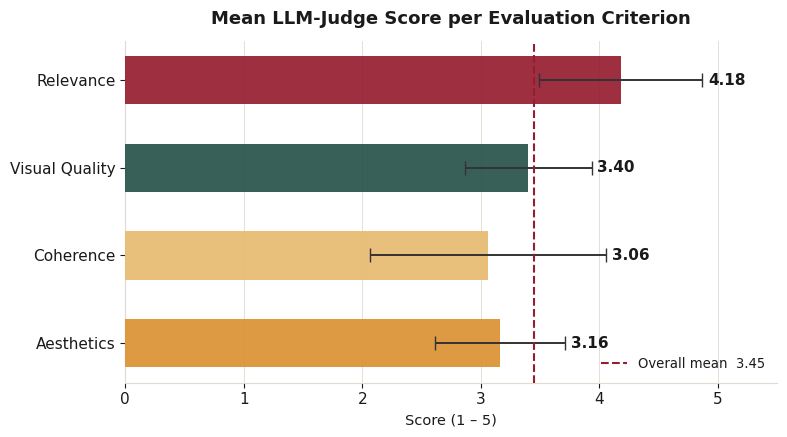

In [26]:

# ──────────────────────────────────────────────────────────────────────────
# 1. Mean Score per Criterion  – horizontal bars with SD ribbons
# ──────────────────────────────────────────────────────────────────────────
means   = np.array([df[c].mean() for c in criteria])
stds    = np.array([df[c].std()  for c in criteria])
overall = df['mean_score'].mean()

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.barh(labels_1L[::-1], means[::-1],
               color=PALETTE[::-1], height=0.55,
               zorder=3, alpha=0.92)

# SD whiskers
for i, (m, s, lbl) in enumerate(zip(means[::-1], stds[::-1], labels_1L[::-1])):
    ax.errorbar(m, i, xerr=s, fmt='none',
                color='#333', linewidth=1.4, capsize=5, zorder=4)
    ax.text(m + s + 0.05, i, f'{m:.2f}', va='center',
            fontsize=11, fontweight='bold', color=C['text'])

ax.axvline(overall, color=C['crimson'], linestyle='--',
           linewidth=1.5, zorder=5,
           label=f'Overall mean  {overall:.2f}')

ax.set_xlim(0, 5.5)
ax.set_xlabel('Score (1 – 5)')
ax.set_title('Mean LLM-Judge Score per Evaluation Criterion', pad=12)
ax.legend(loc='lower right', framealpha=0.0, fontsize=9.5)
ax.grid(axis='y', visible=False)

plt.tight_layout()
plt.savefig(PLOT_DIR / '01_mean_scores.png', dpi=150, bbox_inches='tight')
plt.show()


## 2 · Score Distributions

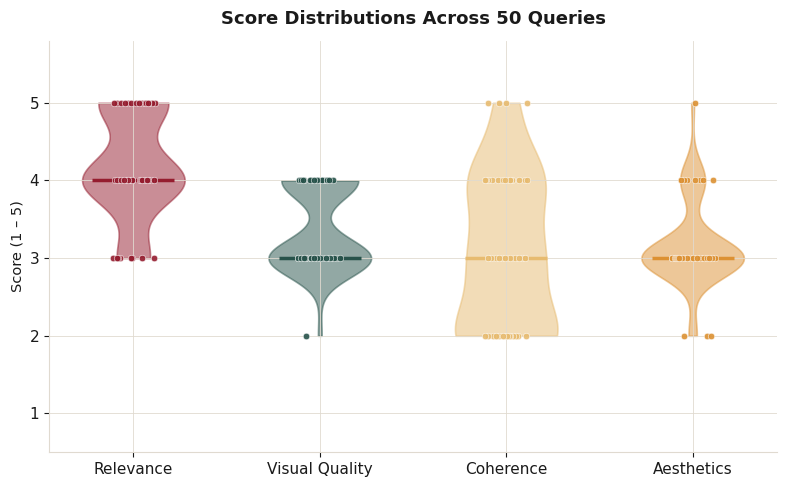

In [27]:

# ──────────────────────────────────────────────────────────────────────────
# 2. Score Distributions – violin + jittered dots
# ──────────────────────────────────────────────────────────────────────────
long_df = (df[criteria]
           .rename(columns=dict(zip(criteria, labels_1L)))
           .melt(var_name='Criterion', value_name='Score'))

fig, ax = plt.subplots(figsize=(8, 5))

vp = ax.violinplot(
    [df[c].values for c in criteria],
    positions=range(len(criteria)),
    widths=0.55, showmedians=False, showextrema=False
)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(PALETTE[i])
    body.set_alpha(0.5)
    body.set_edgecolor(PALETTE[i])
    body.set_linewidth(1.2)

# Median line
for i, c in enumerate(criteria):
    med = df[c].median()
    ax.hlines(med, i - 0.22, i + 0.22,
              color=PALETTE[i], linewidth=2.5, zorder=4)

# Jittered dots
rng = np.random.default_rng(42)
for i, c in enumerate(criteria):
    jitter = rng.uniform(-0.12, 0.12, size=len(df))
    ax.scatter(i + jitter, df[c].values,
               color=PALETTE[i], alpha=0.90, s=22, zorder=5,
               edgecolors='white', linewidth=0.4)

ax.set_xticks(range(len(criteria)))
ax.set_xticklabels(labels_1L)
ax.set_ylim(0.5, 5.8)
ax.set_ylabel('Score (1 – 5)')
ax.set_title('Score Distributions Across 50 Queries', pad=12)

plt.tight_layout()
plt.savefig(PLOT_DIR / '02_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 3 · Routing Overview

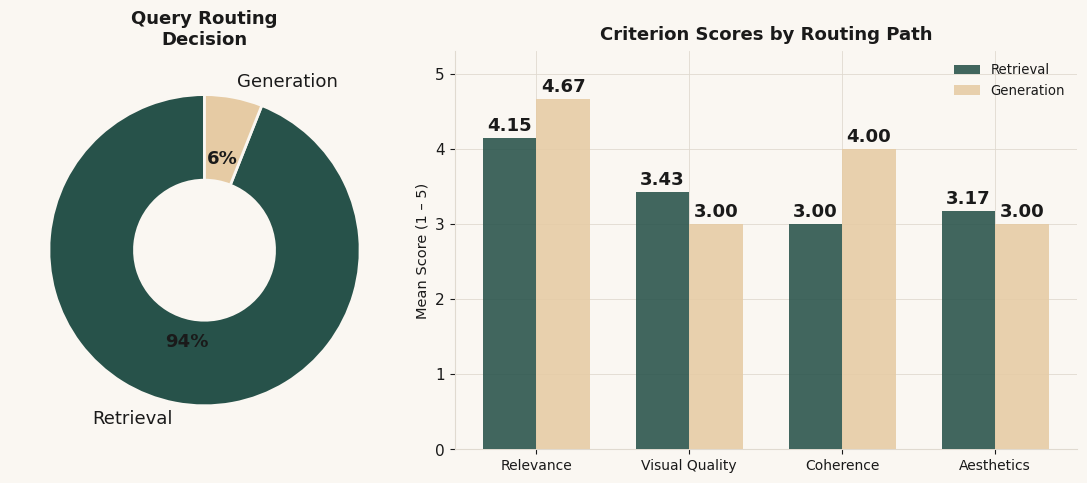

In [32]:

# ──────────────────────────────────────────────────────────────────────────
# 3. Routing Overview – donut + per-route mean scores
# ──────────────────────────────────────────────────────────────────────────
counts = df['routing_decision'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8),
                                gridspec_kw={'width_ratios': [1, 1.6]})

# Donut
wedges, texts, autotexts = ax1.pie(
    counts.values,
    labels=counts.index.str.capitalize(),
    colors=[C['teal'], '#e6cba4'],
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': C['bg'], 'linewidth': 2},
    textprops={'fontsize': 13}
)
for at in autotexts:
    at.set_fontweight('bold')
ax1.set_title('Query Routing\nDecision', pad=8)

# Grouped bar per criterion
route_means = (df.groupby('routing_decision')[criteria]
                 .mean()
                 .rename(columns=dict(zip(criteria, labels_1L))))
x = np.arange(len(labels_1L))
w = 0.35
for j, (route, color) in enumerate(zip(['retrieval','generation'],
                                        [C['teal'], '#e6cba4'])):
    if route not in route_means.index:
        continue
    vals = route_means.loc[route].values
    bars = ax2.bar(x + j*w - w/2, vals, width=w,
                   color=color, alpha=0.88, label=route.capitalize(),
                   zorder=3)
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 v + 0.04, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=13, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(labels_1L, fontsize=10)
ax2.set_ylim(0, 5.3)
ax2.set_ylabel('Mean Score (1 – 5)')
ax2.set_title('Criterion Scores by Routing Path', pad=8)
ax2.legend(framealpha=0.0, fontsize=9.5)

plt.tight_layout()
plt.savefig(PLOT_DIR / '03_routing_overview.png', dpi=150, bbox_inches='tight')
plt.show()


## 4 · Hybrid Score Analysis

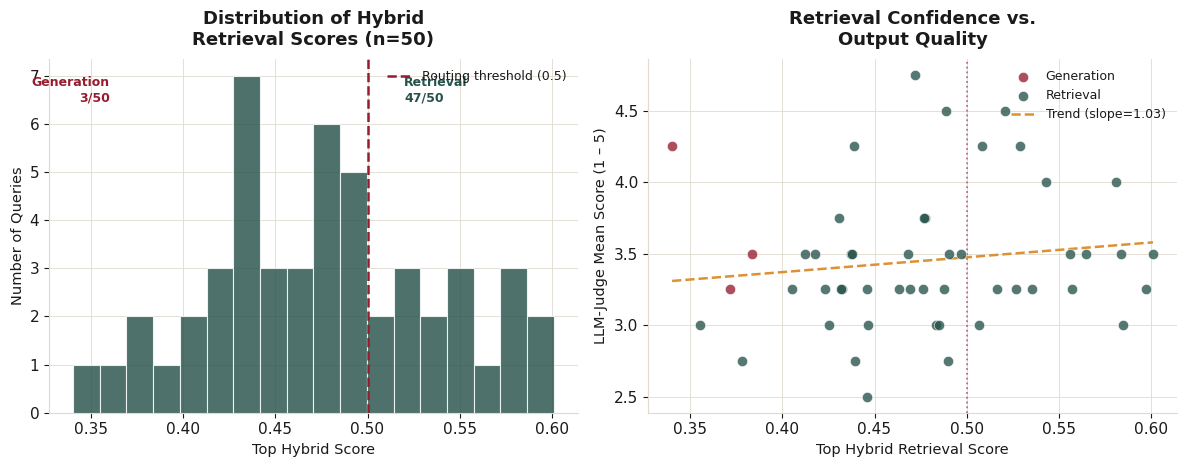

In [29]:

# ──────────────────────────────────────────────────────────────────────────
# 4. Hybrid Score: distribution + quality scatter
# ──────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

# Left: histogram
ax1.hist(df['top_hybrid_score'], bins=18,
         color=C['teal'], alpha=0.82, edgecolor=C['bg'], linewidth=0.8,
         zorder=3)
ax1.axvline(0.5, color=C['crimson'], linestyle='--', linewidth=1.8,
            label='Routing threshold (0.5)', zorder=4)
ax1.set_xlabel('Top Hybrid Score')
ax1.set_ylabel('Number of Queries')
ax1.set_title('Distribution of Hybrid\nRetrieval Scores (n=50)', pad=10)
ax1.legend(framealpha=0.0, fontsize=9)

n_ret = (df['routing_decision']=='retrieval').sum()
n_gen = (df['routing_decision']=='generation').sum()
ymax  = ax1.get_ylim()[1]
ax1.text(0.52, ymax*0.88, f'Retrieval\n{n_ret}/50',
         color=C['teal'], fontsize=9, fontweight='bold')
ax1.text(0.36, ymax*0.88, f'Generation\n{n_gen}/50',
         color=C['crimson'], fontsize=9, fontweight='bold', ha='right')

# Right: scatter retrieval conf vs quality
pal_map = {'retrieval': C['teal'], 'generation': C['crimson']}
for route, grp in df.groupby('routing_decision'):
    ax2.scatter(grp['top_hybrid_score'], grp['mean_score'],
                color=pal_map[route], label=route.capitalize(),
                alpha=0.78, s=55, edgecolors='white', linewidth=0.5, zorder=4)

# trend line
m, b = np.polyfit(df['top_hybrid_score'], df['mean_score'], 1)
xs = np.linspace(df['top_hybrid_score'].min(), df['top_hybrid_score'].max(), 100)
ax2.plot(xs, m*xs+b, color=C['amber'], linewidth=1.8,
         linestyle='--', label=f'Trend (slope={m:.2f})', zorder=3)
ax2.axvline(0.5, color=C['crimson'], linestyle=':', linewidth=1.3, alpha=0.6, zorder=2)

ax2.set_xlabel('Top Hybrid Retrieval Score')
ax2.set_ylabel('LLM-Judge Mean Score (1 – 5)')
ax2.set_title('Retrieval Confidence vs.\nOutput Quality', pad=10)
ax2.legend(framealpha=0.0, fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / '04_hybrid_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 5 · Best & Worst Queries

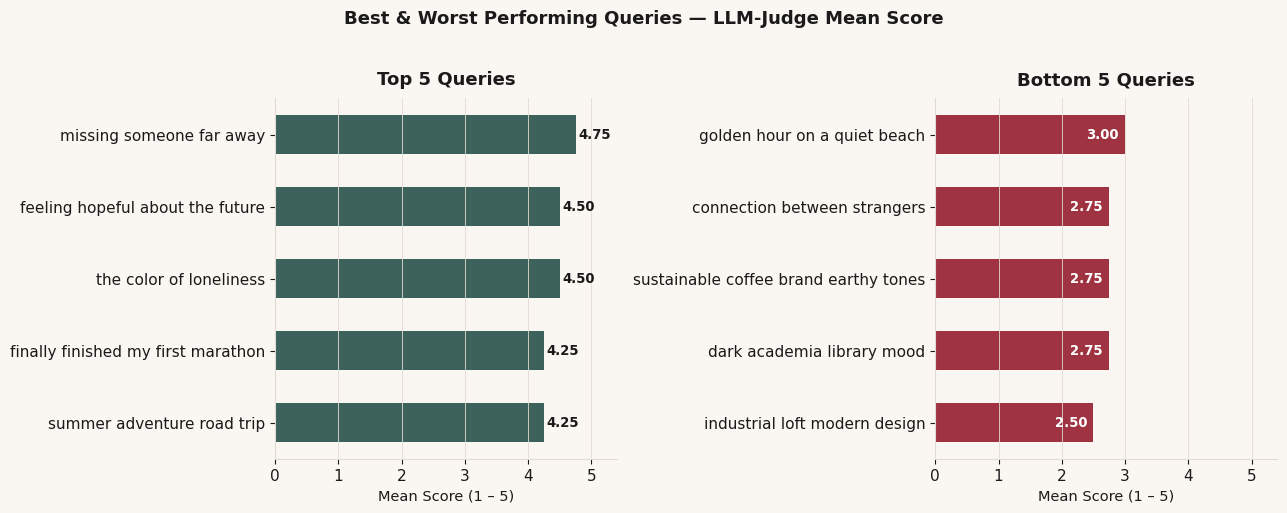

In [18]:

# ──────────────────────────────────────────────────────────────────────────
# 5. Best & Worst Performing Queries
# ──────────────────────────────────────────────────────────────────────────
def wrap(s, w=38):
    return '\n'.join(textwrap.wrap(s, w))

top5    = df.nlargest(5,  'mean_score')[['query','mean_score']].iloc[::-1].copy()
bottom5 = df.nsmallest(5, 'mean_score')[['query','mean_score']].copy()
top5['label']    = top5['query'].apply(wrap)
bottom5['label'] = bottom5['query'].apply(wrap)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

def score_bar(ax, data, color, title, val_side='right'):
    bars = ax.barh(data['label'], data['mean_score'],
                   color=color, height=0.55, alpha=0.90)
    for bar, v in zip(bars, data['mean_score']):
        if val_side == 'right':
            ax.text(v + 0.04, bar.get_y() + bar.get_height()/2,
                    f'{v:.2f}', va='center', fontsize=9.5, fontweight='bold')
        else:
            ax.text(max(v - 0.1, 0.1), bar.get_y() + bar.get_height()/2,
                    f'{v:.2f}', va='center', ha='right',
                    fontsize=9.5, fontweight='bold', color='white')
    ax.set_xlim(0, 5.4)
    ax.set_xlabel('Mean Score (1 – 5)')
    ax.set_title(title, pad=10)
    ax.grid(axis='y', visible=False)

score_bar(ax1, top5,    C['teal'],    'Top 5 Queries',    val_side='right')
score_bar(ax2, bottom5, C['crimson'], 'Bottom 5 Queries', val_side='left')

fig.suptitle('Best & Worst Performing Queries — LLM-Judge Mean Score',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / '05_top_bottom.png', dpi=150, bbox_inches='tight')
plt.show()


## 6 · Correlation Heatmap

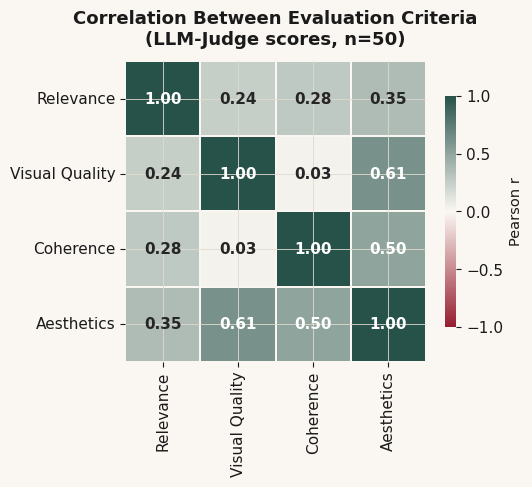

In [19]:

# ──────────────────────────────────────────────────────────────────────────
# 6. Correlation Heatmap
# ──────────────────────────────────────────────────────────────────────────
corr = df[criteria].rename(columns=dict(zip(criteria,labels_1L))).corr()

fig, ax = plt.subplots(figsize=(5.5, 4.8))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# custom diverging palette between brand teal and crimson
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    'brand', [C['crimson'], C['bg'], C['teal']], N=256)

sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap,
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=1.2, linecolor=C['bg'],
            cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
            ax=ax, annot_kws={'size': 11, 'weight': 'bold'})

ax.set_title('Correlation Between Evaluation Criteria\n(LLM-Judge scores, n=50)', pad=12)
plt.tight_layout()
plt.savefig(PLOT_DIR / '06_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


## 7 · Radar Chart – Score Profile

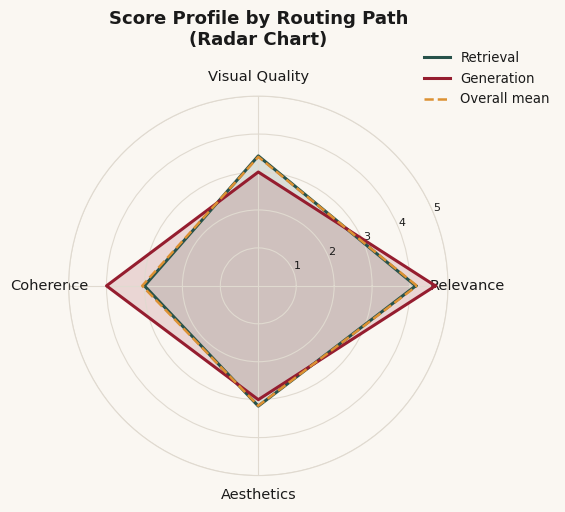

In [20]:

# ──────────────────────────────────────────────────────────────────────────
# 7. Radar Chart – mean scores by routing path
# ──────────────────────────────────────────────────────────────────────────
route_data = df.groupby('routing_decision')[criteria].mean()
N = len(criteria)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]                    # close loop

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
ax.set_facecolor(C['bg'])
fig.patch.set_facecolor(C['bg'])

for route, color in [('retrieval', C['teal']), ('generation', C['crimson'])]:
    if route not in route_data.index:
        continue
    vals = route_data.loc[route].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=color, linewidth=2.2, label=route.capitalize())
    ax.fill(angles, vals, alpha=0.15, color=color)

# Overall mean
overall_vals = [df[c].mean() for c in criteria] 
overall_vals += overall_vals[:1]
ax.plot(angles, overall_vals, color=C['amber'], linewidth=1.8,
        linestyle='--', label='Overall mean')

ax.set_thetagrids(np.degrees(angles[:-1]), labels_1L, fontsize=10.5)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1','2','3','4','5'], fontsize=8, color='#666')
ax.tick_params(colors=C['text'])
ax.grid(color=C['grid'], linewidth=0.8)
ax.spines['polar'].set_color(C['grid'])

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15),
          framealpha=0.0, fontsize=9.5)
ax.set_title('Score Profile by Routing Path\n(Radar Chart)', pad=18,
             fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig(PLOT_DIR / '07_radar.png', dpi=150, bbox_inches='tight')
plt.show()


## 8 · Per-Query Score Heatmap

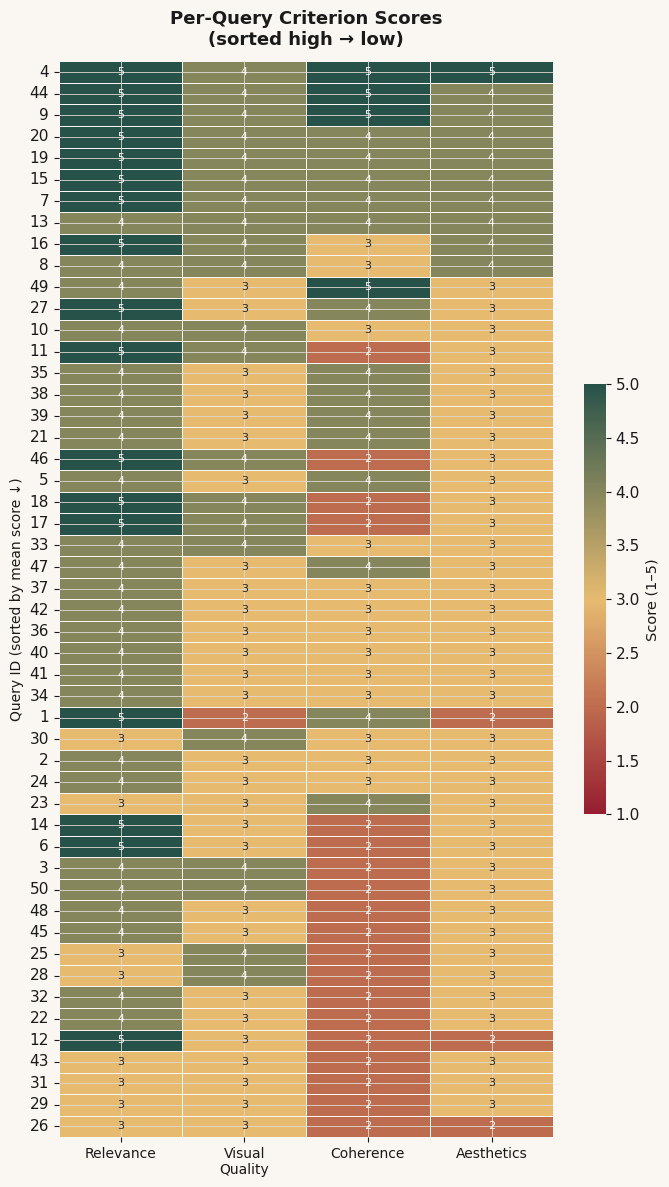

In [21]:

# ──────────────────────────────────────────────────────────────────────────
# 8. Per-query score heatmap (sorted by mean_score)
# ──────────────────────────────────────────────────────────────────────────
heat_df = (df.sort_values('mean_score', ascending=False)
             [['query_id'] + criteria]
             .set_index('query_id'))

fig, ax = plt.subplots(figsize=(7, 12))

from matplotlib.colors import LinearSegmentedColormap
heat_cmap = LinearSegmentedColormap.from_list(
    'heat', [C['crimson'], C['gold'], C['teal']], N=256)

sns.heatmap(heat_df, annot=True, fmt='d', cmap=heat_cmap,
            vmin=1, vmax=5, linewidths=0.4, linecolor=C['bg'],
            cbar_kws={'label': 'Score (1–5)', 'shrink': 0.4},
            ax=ax, annot_kws={'size': 8})

ax.set_xticklabels(['Relevance','Visual\nQuality','Coherence','Aesthetics'],
                   fontsize=10)
ax.set_ylabel('Query ID (sorted by mean score ↓)', fontsize=10)
ax.set_title('Per-Query Criterion Scores\n(sorted high → low)', pad=12,
             fontweight='bold')

plt.tight_layout()
plt.savefig(PLOT_DIR / '08_query_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 9 · Dashboard – Retrieval Mix & KPIs

/var/folders/1f/twjj6zg12057l62kw8fwf3f40000gn/T/ipykernel_85599/772241125.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=plt.cm.get_cmap('RdYlGn'), s=55,
/var/folders/1f/twjj6zg12057l62kw8fwf3f40000gn/T/ipykernel_85599/772241125.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby('ret_bin')[criteria].mean()


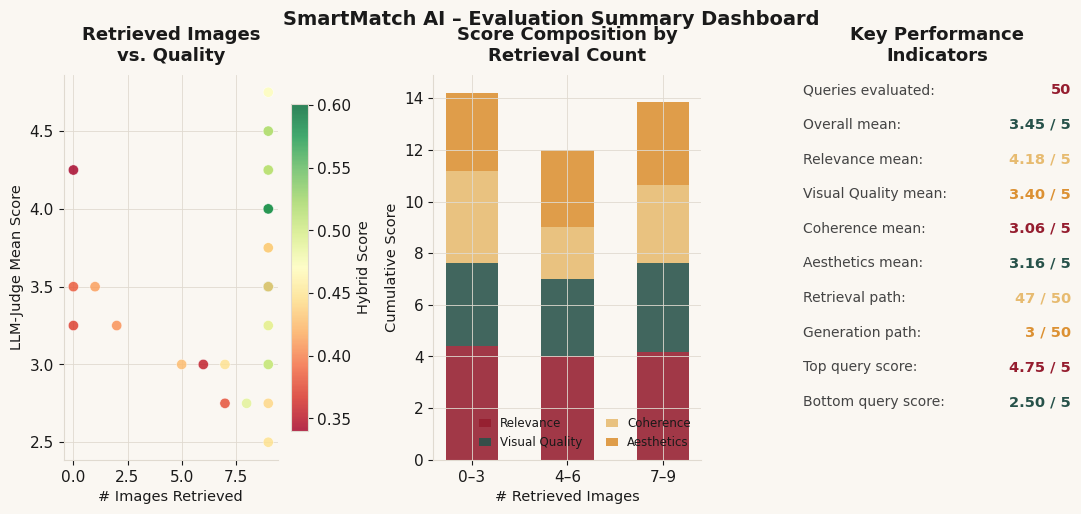

In [22]:

# ──────────────────────────────────────────────────────────────────────────
# 9. Retrieval Mix vs Quality  +  KPI Summary panel
# ──────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ── Left: scatter n_retrieved vs mean_score
sc = ax1.scatter(df['n_retrieved'], df['mean_score'],
                 c=df['top_hybrid_score'],
                 cmap=plt.cm.get_cmap('RdYlGn'), s=55,
                 alpha=0.82, edgecolors='white', linewidth=0.4, zorder=4)
plt.colorbar(sc, ax=ax1, label='Hybrid Score', shrink=0.85)
ax1.set_xlabel('# Images Retrieved')
ax1.set_ylabel('LLM-Judge Mean Score')
ax1.set_title('Retrieved Images\nvs. Quality', pad=10)

# ── Middle: stacked bar – n_retrieved / n_generated ratio
bins = [0,3,6,9]
labels_bins = ['0–3','4–6','7–9']
df['ret_bin'] = pd.cut(df['n_retrieved'], bins=bins,
                        labels=labels_bins, include_lowest=True)
grp = df.groupby('ret_bin')[criteria].mean()
x   = np.arange(len(grp))
bottom = np.zeros(len(grp))
for ci, (c, color) in enumerate(zip(criteria, PALETTE)):
    vals = grp[c].values
    ax2.bar(x, vals, bottom=bottom, color=color,
            alpha=0.88, label=labels_1L[ci], width=0.55)
    bottom += vals

ax2.set_xticks(x)
ax2.set_xticklabels(labels_bins)
ax2.set_xlabel('# Retrieved Images')
ax2.set_ylabel('Cumulative Score')
ax2.set_title('Score Composition by\nRetrieval Count', pad=10)
ax2.legend(fontsize=8.5, framealpha=0.0, loc='lower right',
           ncol=2, handlelength=1)

# ── Right: KPI text summary
ax3.axis('off')
kpis = [
    ('Queries evaluated',   f'{len(df)}'),
    ('Overall mean',        f'{df["mean_score"].mean():.2f} / 5'),
    ('Relevance mean',      f'{df["Relevance"].mean():.2f} / 5'),
    ('Visual Quality mean', f'{df["Visual_Quality"].mean():.2f} / 5'),
    ('Coherence mean',      f'{df["Coherence"].mean():.2f} / 5'),
    ('Aesthetics mean',     f'{df["Aesthetics"].mean():.2f} / 5'),
    ('Retrieval path',      f'{(df.routing_decision=="retrieval").sum()} / {len(df)}'),
    ('Generation path',     f'{(df.routing_decision=="generation").sum()} / {len(df)}'),
    ('Top query score',     f'{df["mean_score"].max():.2f} / 5'),
    ('Bottom query score',  f'{df["mean_score"].min():.2f} / 5'),
]
for i, (k, v) in enumerate(kpis):
    y = 0.95 - i * 0.09
    color = PALETTE[i % len(PALETTE)]
    ax3.text(0.0, y, k + ':', transform=ax3.transAxes,
             fontsize=10, color='#444')
    ax3.text(1.0, y, v, transform=ax3.transAxes,
             fontsize=10.5, fontweight='bold', color=color, ha='right')

ax3.set_title('Key Performance\nIndicators', pad=10, fontweight='bold')

plt.suptitle('SmartMatch AI – Evaluation Summary Dashboard',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig(PLOT_DIR / '09_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
